Connected to Python 3.9.6

Connected to base (Python 3.12.7)

In [1]:
import os
import scanpy as sc
from utils import compute_nn
import pandas as pd
import numpy as np
import pickle
import random
random.seed(2025)
import sys
sys.path.append('/Users/zhaoyimin/Desktop/SCOPE Manuscipt')
from branchpoint_localization import trace_to_highest_density_point
os.chdir('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Palantir/iter100_alpha0.1_omit0.02_trees10')

### prepare the data

In [2]:
# Load data and conformal results
data = sc.read_h5ad('./data_complete_results.h5ad')
with open('./conformal_result.pkl', 'rb') as f:
    conformal_result = pickle.load(f)

pseudo_time_ranks = np.argsort(data.obs['palantir_pseudotime'][data.obs['cluster'] == 'TBD'].values)
pseudo_time_ranks = pseudo_time_ranks[::-1]
cells2recruit_barcode = data[data.obs['cluster'] == 'TBD'][pseudo_time_ranks,:].obs_names
data_subset = data[cells2recruit_barcode]

# Get prediction sets from conformal results
prediction_set = conformal_result['prediction_set'].copy()

# Define conditions for different prediction set combinations
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Ery'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Mono'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Ery', 'Mono'})
]

### 1. plot cells with prediction set {Mono} {Ery} {Mono, Ery}

([], [])

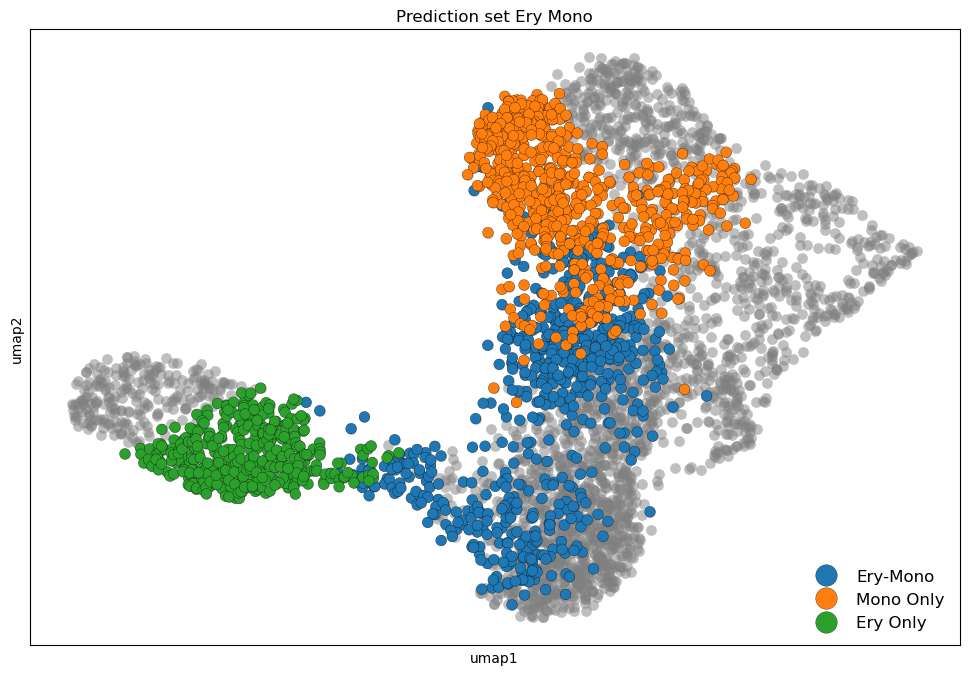

In [3]:
barcode_ery = prediction_set[conditions[0]].index
barcode_mono = prediction_set[conditions[1]].index
barcode_ery_mono = prediction_set[conditions[2]].index

combined_barcode = barcode_ery_mono.append(barcode_mono).append(barcode_ery)

df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['cluster'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_ery, 'Labels'] = 'Ery Only'
df.loc[barcode_mono, 'Labels'] = 'Mono Only'
df.loc[barcode_ery_mono, 'Labels'] = 'Ery-Mono'

#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(12, 8))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None
    , s=60, linewidth=0,legend=False, alpha = 0.5
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df.loc[combined_barcode]
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    edgecolor='black', linewidth=0.2, s=60, hue='Labels',  # Different color for each class
     palette='tab10'
)

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=12, frameon=False)
plt.title('Prediction set Ery Mono')
plt.xlabel('umap1')
plt.ylabel('umap2')
plt.xticks([])
plt.yticks([])

### 2. do density clustering and get branchpoint

In [4]:
# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_mono_ery = prediction_set[combined_condition].index

#subset dataset
data_subset_mono_ery = data[barcode_mono_ery]

#calculate KNN graph
distance, indices = compute_nn(data_subset_mono_ery.obsm['X_pca'], 35)

#do density clustering in new KNN graph
density = data_subset_mono_ery.obs['mellon_log_density'].to_list()


# Step 1: Create label list and index mapping
unique_labels = ['Mono', 'Ery']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_mono_ery.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_mono_ery]['prediction_set']):
    for label in label_set:
        if label in label_to_idx:
            label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])


clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_mono_ery.obsm['X_pca'].shape[0]):
    #if i not in visited:
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]


center_most_mono_ery = np.nan
most_mono_ery  = 0
for center, points in clusters.items():
    barcode = barcode_mono_ery[points]
    # Count cells with both Mono and Ery in prediction set
    num_mono_ery = 0
    for bc in barcode:
        if bc in prediction_set.index:
            pred_set = prediction_set.loc[bc, 'prediction_set']
            if 'Mono' in pred_set and 'Ery' in pred_set:
                num_mono_ery += 1

    if num_mono_ery > most_mono_ery:
        most_mono_ery = num_mono_ery
        center_most_mono_ery = center

barcode_branchpoint = barcode_mono_ery[clusters[center_most_mono_ery]]

### plot the branchpoint in umap embedding 

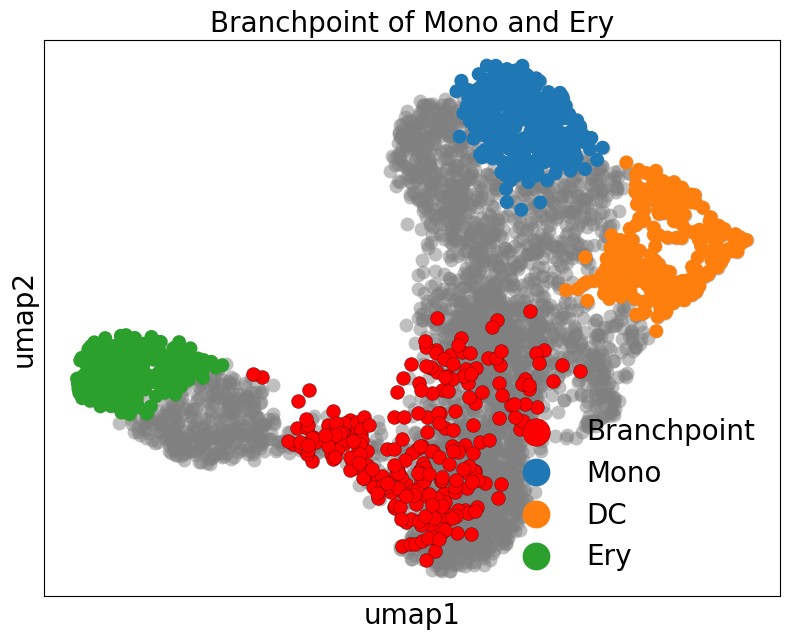

In [5]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['cluster'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint, 'Labels'] = 'Branchpoint'


#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

#plt.figure(figsize=(12, 8))
plt.figure(figsize=(8, 6.5))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None, s=100, linewidth=0, alpha=0.5, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='red', edgecolor='black', linewidth=0.2, s=100, label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=100, linewidth=0, alpha=1, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=20, frameon=False)
plt.title('Branchpoint of Mono and Ery', fontsize=20)
plt.xlabel('umap1', fontsize=20)
plt.ylabel('umap2', fontsize=20)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig('./branchpoint_mono_ery.png', dpi=400)

### plot the branchpoint in umap embedding (vector plot)

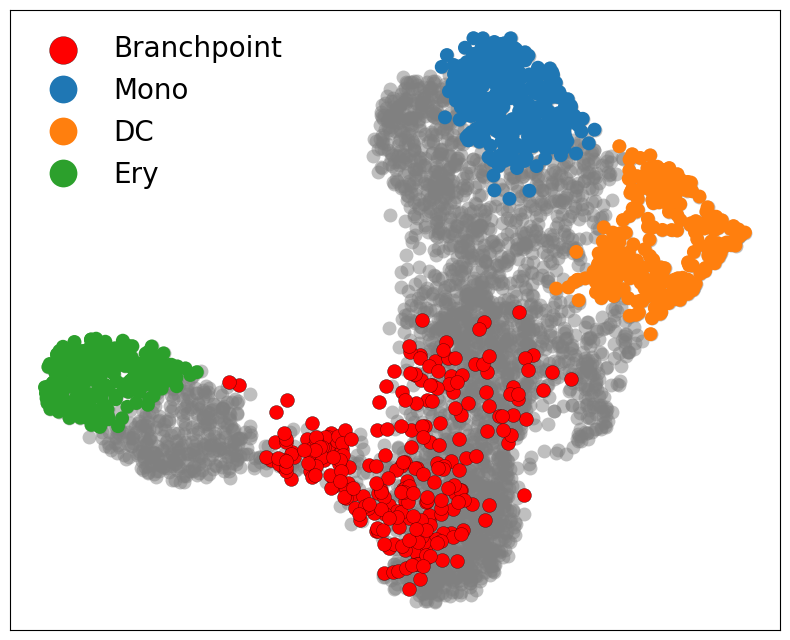

In [8]:
#plt.figure(figsize=(12, 8))
plt.figure(figsize=(8, 6.5))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None, s=100, linewidth=0, alpha=0.5, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='red', edgecolor='black', linewidth=0.2, s=100, label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=100, linewidth=0, alpha=1, legend='brief'
    )


# Clean up and finalize
plt.legend(loc='upper left', markerscale=2.0,  fontsize=20, frameon=False)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Palantir/vector plot/branchpoint_mono_ery.pdf')


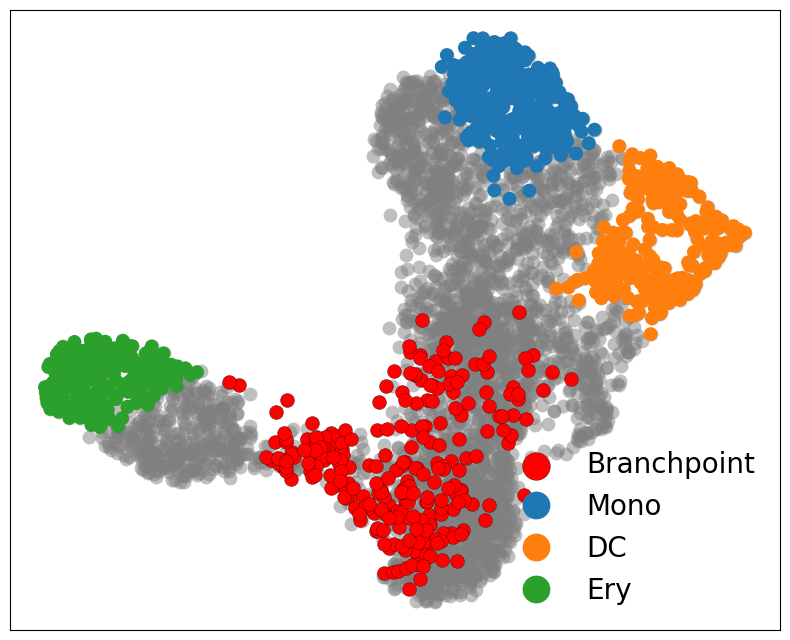

In [11]:
import pandas as pd
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['cluster'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint, 'Labels'] = 'Branchpoint'


#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

#plt.figure(figsize=(12, 8))
plt.figure(figsize=(8, 6.5))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='grey', edgecolor=None, s=100, linewidth=0, alpha=0.5, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='red', edgecolor='black', linewidth=0.2, s=100, label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=100, linewidth=0, alpha=1, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=20, frameon=False)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig('./branchpoint_mono_ery_noxylabel.png', dpi=400)

In [6]:
data_mono_ery_branchpoint = data[barcode_branchpoint]
data_mono_ery_branchpoint.write_h5ad('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/tradeseq new/bp candidate1/palantir_data_mono_ery_branchpoint.h5ad')

### 3. subsample dataset for 500 trials and derive the p value

Coefficient (slope): -0.6794
Intercept: 0.7141


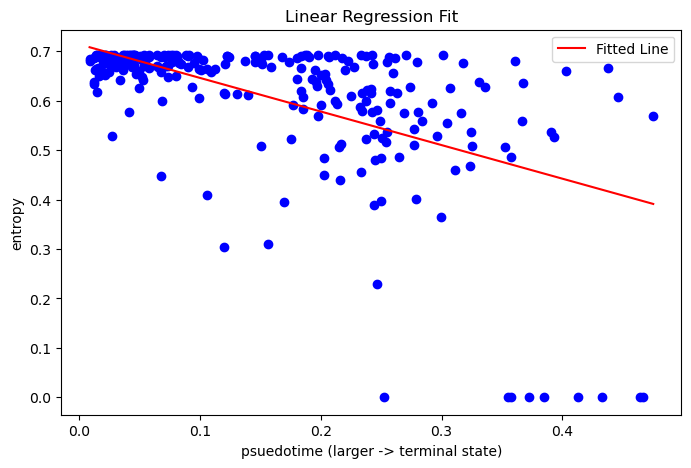

In [12]:
from scipy.stats import entropy
data_branchpoint = data[barcode_branchpoint]

branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)

df_pseudotime_entropy = pd.DataFrame({'pseudotime':branchpoint_pseudotime, 'entropy': branchpoint_entropy})


#pseudotime 1 will be terminal state
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Fit linear regression
model = LinearRegression()
model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())

# Report coefficients
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Predict y values for plotting
x_vals = np.linspace(df_pseudotime_entropy['pseudotime'].min(), df_pseudotime_entropy['pseudotime'].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_vals)
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_pseudotime_entropy['pseudotime'], df_pseudotime_entropy['entropy'], color='blue')
plt.plot(x_vals, y_pred, color='red', label='Fitted Line')
plt.xlabel('psuedotime (larger -> terminal state)')
plt.ylabel('entropy')
plt.title('Linear Regression Fit')
plt.legend()
plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/Palantir/appendix plot/branchpoint_mono_ery_entropy_vs_pseudotime.png', dpi=300)
#plt.show()


slope = model.coef_[0]

In [ ]:
import matplotlib.pyplot as plt

# res is your vector (e.g., list, NumPy array, or pandas Series)
plt.figure(figsize=(8, 7))

# Plot histogram
plt.hist(res, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical line (remove fontsize parameter)
plt.axvline(x=-2.56, color='red', linestyle='--', linewidth=2, label='Slope branchpoint (-14.56)')

# Add labels and legend
plt.xlabel('')
plt.ylabel('')
plt.title('')
plt.xticks([])
plt.yticks([])
plt.legend(fontsize=15)  # Move fontsize to legend

plt.tight_layout()

### 4. check variable importance

#### 4.1 Variable importance for Ery lineage

In [7]:
# Calculate weighted variable importance specifically for Ery lineage
unique_iterations = set(data[barcode_branchpoint].obs['iteration_recruited'])
#print(f"Unique iterations: {sorted(unique_iterations)}")

# Calculate proportion of cells for each iteration (weights)
iteration_counts = data[barcode_branchpoint].obs['iteration_recruited'].value_counts()
total_cells = len(barcode_branchpoint)
iteration_weights = iteration_counts / total_cells

# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Ery lineage specifically (only for HVGs)
weighted_importance_ery = np.zeros(hvg_mask.sum())

# Calculate weighted sum across all iterations for Ery column
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Get variable importance for this iteration
        importance = data.varm[feature_importance_key]
        # Filter to HVGs and extract Ery column specifically
        importance_hvg = importance[hvg_mask]
        weight = iteration_weights[iter_id]
        weighted_importance_ery += weight * importance_hvg['Ery'].values
        #print(f"Added iteration {iter_id} (Ery) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Create DataFrame with Ery-specific results (using only HVG gene names)
importance_ery_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_ery': weighted_importance_ery
})

# Sort by Ery importance
importance_ery_df = importance_ery_df.sort_values('weighted_importance_ery', ascending=False)
print(f"\nTop 20 most important features for Ery lineage (HVGs only):")
print(importance_ery_df.head(20))

importance_ery_df.to_csv('./palantir_variable_importance_ery.csv')


Top 20 most important features for Ery lineage (HVGs only):
           gene  weighted_importance_ery
1814     CNRIP1                 0.017110
939        KLF1                 0.016924
4262      KCNH2                 0.016685
3195        CKB                 0.016250
2001       TFR2                 0.015703
2649    ZFP36L1                 0.015404
784     ALDH1A1                 0.014006
4090  LINC00152                 0.013697
1259    TMEM246                 0.013263
3468      EPHX2                 0.013011
386       CECR1                 0.012275
3501       TAL1                 0.012185
2598      GATA1                 0.012128
4145   TMEM150C                 0.011742
1537    ARHGAP6                 0.011730
883     ST6GAL2                 0.011646
3331     UBE2E2                 0.011368
1463       PTRF                 0.011125
2216       ANK1                 0.010776
1546      MYH10                 0.010472


#### check the rank of 2 important TFs(GATA1, GATA2) Manu mentioned

In [9]:
# Check ranks of GATA1 and GATA2 in Ery importance ranking
# Reset index to get proper ranking after sorting
importance_ery_df_ranked = importance_ery_df.reset_index(drop=True)

genes_to_check = ['GATA1', 'GATA2']

print("Important TF rankings in Ery-specific importance:")
print("-" * 50)

print(f"\nTotal number of genes: {np.sum(data.var['highly_variable'])}")
for gene in genes_to_check:
    if gene in importance_ery_df_ranked['gene'].values:
        # Find the position in the sorted DataFrame (0-indexed, so add 1 for rank)
        gene_position = importance_ery_df_ranked[importance_ery_df_ranked['gene'] == gene].index[0]
        rank = gene_position + 1
        importance_score = importance_ery_df_ranked[importance_ery_df_ranked['gene'] == gene]['weighted_importance_ery'].values[0]
        print(f"{gene}: Rank {rank}, Ery Importance: {importance_score:.6f}")
        print(f"{gene}: Quantile: {rank / np.sum(data.var['highly_variable']):.4f}")
    else:
        print(f"{gene}: Not found in dataset")


Important TF rankings in Ery-specific importance:
--------------------------------------------------

Total number of genes: 4281
GATA1: Rank 6, Ery Importance: 0.014818
GATA1: Quantile: 0.0014
GATA2: Rank 96, Ery Importance: 0.003520
GATA2: Quantile: 0.0224


#### TF Analysis: GATA1 and GATA2 ranks among transcription factors

In [10]:
# Load TF list and extract Symbol column
tf_list_path = '/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure4 Seacell Palantir/TF list.txt'
tf_df = pd.read_csv(tf_list_path, sep='\t')

# Extract Symbol column
tf_symbols = tf_df['Symbol'].tolist()
print(f"Total number of TF symbols: {len(tf_symbols)}")

# Find overlap between highly variable genes and TF symbols
hvg_genes = data.var_names[data.var['highly_variable']].tolist()
tf_hvg_overlap = [gene for gene in tf_symbols if gene in hvg_genes]
print(f"Number of TFs that are also highly variable genes: {len(tf_hvg_overlap)}")
print(f"TF-HVG overlap genes: {tf_hvg_overlap[:10]}...")  # Show first 10

# Subset importance_ery_df to only include TFs that are in highly variable genes
tf_importance_ery = importance_ery_df[importance_ery_df['gene'].isin(tf_hvg_overlap)].copy()
tf_importance_ery = tf_importance_ery.reset_index(drop=True)

print(f"\nTop 10 TFs by Ery importance (among HVGs):")
print(tf_importance_ery.head(10))

Total number of TF symbols: 1220
Number of TFs that are also highly variable genes: 304
TF-HVG overlap genes: ['AFF1', 'AFF4', 'AHR', 'AR', 'ARID2', 'ARID3A', 'ARID5A', 'ARID5B', 'ARNT', 'ARNT2']...

Top 10 TFs by Ery importance (among HVGs):
      gene  weighted_importance_ery
0  ZFP36L1                 0.015729
1     KLF1                 0.014871
2    GATA1                 0.014818
3    GFI1B                 0.010914
4     TAL1                 0.007642
5     NFIA                 0.005654
6   ZNF792                 0.004852
7      MYC                 0.004672
8  TSC22D1                 0.004200
9    GATA2                 0.003520


In [11]:
# Report GATA1 and GATA2 ranks among TFs only
genes_to_check = ['GATA1', 'GATA2']

print("GATA1 and GATA2 rankings among transcription factors:")
print("=" * 55)
print(f"Total TFs analyzed: {len(tf_importance_ery)}")
print()

for gene in genes_to_check:
    if gene in tf_importance_ery['gene'].values:
        # Find rank among TFs
        tf_rank = tf_importance_ery[tf_importance_ery['gene'] == gene].index[0] + 1
        importance_score = tf_importance_ery[tf_importance_ery['gene'] == gene]['weighted_importance_ery'].values[0]
        tf_quantile = tf_rank / len(tf_importance_ery)
        
        print(f"{gene}:")
        print(f"  Rank among TFs: {tf_rank} out of {len(tf_importance_ery)}")
        print(f"  Importance score: {importance_score:.6f}")
        print(f"  Percentile among TFs: {(1-tf_quantile)*100:.1f}th percentile")
        print()
    else:
        print(f"{gene}: Not found in TF-HVG overlap")
        print()

GATA1 and GATA2 rankings among transcription factors:
Total TFs analyzed: 304

GATA1:
  Rank among TFs: 3 out of 304
  Importance score: 0.014818
  Percentile among TFs: 99.0th percentile

GATA2:
  Rank among TFs: 10 out of 304
  Importance score: 0.003520
  Percentile among TFs: 96.7th percentile



#### 4.2 Variable importance for Mono lineage

In [8]:
# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Mono lineage specifically (only for HVGs)
weighted_importance_mono = np.zeros(hvg_mask.sum())

# Calculate weighted sum across all iterations for Mono column
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Get variable importance for this iteration
        importance = data.varm[feature_importance_key]
        # Filter to HVGs and extract Mono column specifically
        importance_hvg = importance[hvg_mask]
        weight = iteration_weights[iter_id]
        weighted_importance_mono += weight * importance_hvg['Mono'].values
        #print(f"Added iteration {iter_id} (Mono) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Create DataFrame with Mono-specific results (using only HVG gene names)
importance_mono_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_mono': weighted_importance_mono
})

# Sort by Mono importance
importance_mono_df = importance_mono_df.sort_values('weighted_importance_mono', ascending=False)
print(f"\nTop 20 most important features for Mono lineage (HVGs only):")
print(importance_mono_df.head(20))

importance_mono_df.to_csv('./palantir_variable_importance_mono.csv')


Top 20 most important features for Mono lineage (HVGs only):
              gene  weighted_importance_mono
955          KALRN                  0.019489
2085         GCHFR                  0.018178
2875      MAP1LC3B                  0.015797
2359      MARCKSL1                  0.014394
515         CCDC69                  0.013612
1795        ELMOD3                  0.013078
1754      APOBEC3C                  0.013073
1382      ANKRD18A                  0.012264
3756      PPP1R14A                  0.011939
250          DEDD2                  0.011640
657   RP11-179K3.2                  0.011510
405            HAL                  0.010963
228         TMEM9B                  0.010608
1157        IQGAP2                  0.010569
1359         TIGD3                  0.010345
3307        SEMA3C                  0.010098
1228          PTMS                  0.010041
3916        SPINT1                  0.009937
3040         DECR1                  0.009932
1928         PTPN1                  0.

In [13]:
importance_mono_df_ranked = importance_mono_df.reset_index(drop=True)

genes_to_check = ['CEBPA', 'SPI1']

print("Important TF rankings in Mono-specific importance:")
print("-" * 50)

print(f"\nTotal number of genes: {np.sum(data.var['highly_variable'])}")
for gene in genes_to_check:
    if gene in importance_mono_df_ranked['gene'].values:
        # Find the position in the sorted DataFrame (0-indexed, so add 1 for rank)
        gene_position = importance_mono_df_ranked[importance_mono_df_ranked['gene'] == gene].index[0]
        rank = gene_position + 1
        importance_score = importance_mono_df_ranked[importance_mono_df_ranked['gene'] == gene]['weighted_importance_mono'].values[0]
        print(f"{gene}: Rank {rank}, Mono Importance: {importance_score:.6f}")
        print(f"{gene}: Quantile: {rank / np.sum(data.var['highly_variable']):.4f}")
    else:
        print(f"{gene}: Not found in dataset")

Important TF rankings in Mono-specific importance:
--------------------------------------------------

Total number of genes: 4281
CEBPA: Rank 216, Mono Importance: 0.000801
CEBPA: Quantile: 0.0505
SPI1: Rank 509, Mono Importance: 0.000209
SPI1: Quantile: 0.1189


In [14]:
# Subset importance_mono_df to only include TFs that are in highly variable genes
tf_importance_mono = importance_mono_df[importance_mono_df['gene'].isin(tf_hvg_overlap)].copy()
tf_importance_mono = tf_importance_mono.reset_index(drop=True)  # Fixed: should reset tf_importance_mono, not tf_importance_ery

print(f"Number of TFs in the mono analysis: {len(tf_importance_mono)}")
print(f"\nTop 15 TFs by Mono importance:")
print(tf_importance_mono.head(15).to_string(index=False))

# Report CEBPA and SPI1 ranks among TFs only
genes_to_check = ['CEBPA', 'SPI1']

print("CEBPA and SPI1 rankings among transcription factors (Mono lineage):")
print("=" * 65)
print(f"Total TFs analyzed: {len(tf_importance_mono)}")
print()

for gene in genes_to_check:
    if gene in tf_importance_mono['gene'].values:
        # Find rank among TFs for MONO importance
        tf_rank = tf_importance_mono[tf_importance_mono['gene'] == gene].index[0] + 1
        importance_score = tf_importance_mono[tf_importance_mono['gene'] == gene]['weighted_importance_mono'].values[0]
        tf_quantile = tf_rank / len(tf_importance_mono)
        
        print(f"{gene}:")
        print(f"  Rank among TFs: {tf_rank} out of {len(tf_importance_mono)}")
        print(f"  Mono importance score: {importance_score:.6f}")
        print(f"  Percentile among TFs: {(1-tf_quantile)*100:.1f}th percentile")
        print()
    else:
        print(f"{gene}: Not found in TF-HVG overlap")
        print()

Number of TFs in the mono analysis: 304

Top 15 TFs by Mono importance:
  gene  weighted_importance_mono
ZNF442                  0.004788
 NR1H2                  0.003925
 SMAD3                  0.003440
  TCF7                  0.002752
NFATC2                  0.002331
  MAFF                  0.002226
 MEF2C                  0.001920
 CEBPD                  0.001776
ZNF224                  0.001612
 NR4A3                  0.001175
 FOSL2                  0.001154
 CEBPE                  0.001124
 GFI1B                  0.001071
 HOXB2                  0.000944
ZNF75A                  0.000936
CEBPA and SPI1 rankings among transcription factors (Mono lineage):
Total TFs analyzed: 304

CEBPA:
  Rank among TFs: 16 out of 304
  Mono importance score: 0.000801
  Percentile among TFs: 94.7th percentile

SPI1:
  Rank among TFs: 36 out of 304
  Mono importance score: 0.000209
  Percentile among TFs: 88.2th percentile

